# **Storytelling Fase 2 - 13DTA - Grupo 14**

A Ciência por Trás de um Grande Vinho
Uma jornada de análise de dados e Machine Learning para prever a qualidade sensorial através da química.

1. O Desafio: A Subjetividade dos Enólogos
A avaliação de um vinho é tradicionalmente um processo caro, demorado e subjetivo, dependendo do paladar de especialistas treinados.</br>
Nosso objetivo foi transformar essa arte em ciência, utilizando o Wine Quality Dataset para prever se um vinho tinto é de Alta Qualidade (nota ≥ 7) ou Baixa/Média Qualidade (nota < 7) com base em 11 variáveis físico-químicas.</br>
</br>

2. O Que os Dados nos Revelaram? (EDA)
Ao explorar as 1.143 amostras, descobrimos um desafio clássico: vinhos de alta qualidade são raros, representando apenas 13,9% do dataset.</br>
Além disso, a análise exploratória confirmou hipóteses fundamentais da enologia
:</br>
**Teor Alcoólico:** Vinhos de alta qualidade tendem a ter um teor alcoólico mais elevado (~11,5%), indicando melhor maturação da uva.</br>
**Acidez Volátil:** É a "inimiga" da qualidade. Níveis altos conferem aroma de vinagre; vinhos premiados apresentam níveis significativamente menores.</br>
**Sulfatos:** Atuam na conservação e estabilidade, estando presentes em níveis mais altos em vinhos de melhor categoria.</br>
</br>

3. Preparando o Terreno (Pré-processamento)
Para garantir que os modelos aprendessem corretamente, realizamos os seguintes tratamentos de dados:</br>
- Verificação de nulos (dataset completo).
- Engenharia de Features: Criamos 4 novas variáveis para capturar nuances químicas, como a razão de SO2 e a relação álcool/densidade.
- Padronização: Utilizamos o StandardScaler para que todas as variáveis tivessem o mesmo peso matemático.
- Combate ao Desbalanceamento: Como os vinhos bons são raros, usamos técnicas como SMOTE (para Random Forest) e scale_pos_weight (para XGBoost) para equilibrar o aprendizado.</br>
</br>

4. O Duelo de Modelos: Random Forest vs. XGBoost
Testamos os dois modelos:</br>
- Modelo A (Random Forest): Treina árvores em paralelo. Obteve um excelente ROC-AUC (0,918), mostrando boa capacidade de separação geral.
- Modelo B (XGBoost): Treina árvores sequencialmente, corrigindo os erros das anteriores.
</br>
**Por que optamos pelo XGBoost?**
- Performance prática e na redução de erros críticos.
- Superioridade em Métricas-Chave: O XGBoost superou o Random Forest em Acurácia (0,900), Precisão (0,629) e, principalmente, no F1-score (0,657).
- Menos Vinhos Bons Desperdiçados: O XGBoost teve um Recall superior (0,688) e menos Falsos Negativos (10 contra 11)
- No contexto de mercado, isso significa que o modelo é melhor em identificar vinhos de alta qualidade que poderiam passar despercebidos.
- Eficiência: O modelo atingiu resultados superiores sem a necessidade de gerar dados sintéticos (oversampling), apenas ajustando pesos internos.</br>
</br>

5. Conclusão:</br>
Os resultados finais apontam que as variáveis que mais impactam na classificação de um vinho como "Alta Qualidade" são, em ordem de importância
:</br>
- **Teor Alcoólico (alcohol):** O principal preditor de qualidade em ambos os modelos.
- **Sulfatos (sulphates):** Essenciais para a estabilidade e conservação.
- **Acidez Volátil (volatile acidity):** Quanto menor, melhor a percepção sensorial.</br>
</br>
Com o modelo sugerido, entendemos que a vinícola dispõe de uma ferramenta robusta para triagem automática, garantindo que os melhores vinhos sejam identificados com precisão técnica, trazendo escala e sustentabilidade para o processo produtivo, com isso podemos fazer testes por amostragem por especialistas na área readequando o modelo de forma ágil.

# **Tech Challenge Fase 2 - 13DTA - Grupo 14**

**1 - COMPREENSÃO DO PROBLEMA**

<br>1.1 - Contexto <br>
O dataset Wine Quality contém informações físico-químicas de 1.143 amostras de vinho tinto, coletadas a partir de análises laboratoriais. Cada amostra possui 11 variáveis preditoras contínuas e uma variável-alvo numérica chamada 'quality', que representa a avaliação sensorial feita por especialistas em uma escala de 0 a 10.<br><br>

1.2 - Variável-alvo <br>
A variável 'quality' assume valores inteiros entre 3 e 8 neste dataset. Para transformar o problema em classificação binária, aplicaremos o seguinte critério: <br>

- Alta qualidade (1): nota >= 7
- Baixa qualidade (0): nota < 7

<br>

1.3 - Justificativa da binarização <br>
A nota 7 é o limiar comumente utilizado na literatura para separar vinhos de qualidade superior. Pela distribuição do dataset, apenas uma minoria das amostras alcança a nota >= 7, o que torna o problema um desafio de classificação desbalanceada - algo importante a considerar na etapa de modelagem. <br>





In [ ]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Carregamento do dataset
df = pd.read_csv("/content/WineQT.csv")

# Removendo a coluna Id (não é uma feature)
df.drop(columns=["Id"], inplace=True)

#Criando a variável-alvo binária
df["high_quality"] = (df["quality"] >= 7).astype(int)

print("Shape do dataset:", df.shape)
print("\nPrimeiras Linhas:")
df.head()

Shape do dataset: (1143, 13)

Primeiras Linhas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


**2 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)**

**2.1 - Visão geral do Dataset**

<br>Verificação das dimensões, tipos de dados e presença de valores nulos.

In [ ]:
print("Dimensões:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores nulos por coluna:")
print(df.isnull().sum())
print("\nEstatísticas descritivas:")
df.describe()

Dimensões: (1143, 13)

Tipos de dados:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
high_quality              int64
dtype: object

Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
high_quality            0
dtype: int64

Estatísticas descritivas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,high_quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,0.139108
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,0.346210
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,0.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1.000000


**2.2 - Distribuição da variável alvo**

<br> Análise da distribuição original da variável 'quality' e, em seguida, balanceamento das classes binárias criadas.

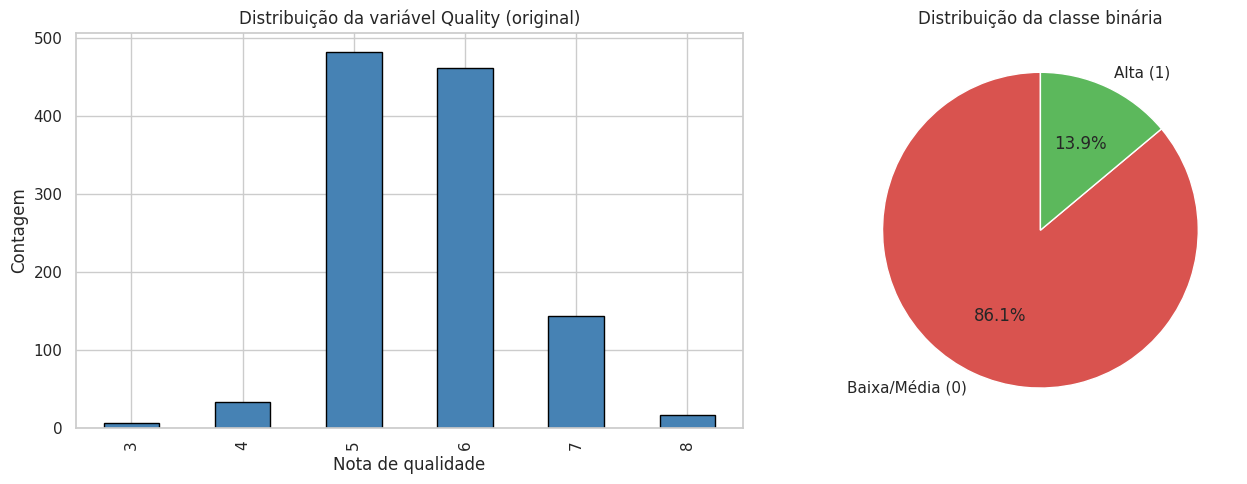

Contagem por classe:
high_quality
0    984
1    159
Name: count, dtype: int64

Percentual Alta Qualidade: 13.9%


In [ ]:
#Cria uma figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Distribuição original (qualidade de 0 a 10)
#Conta a frequência de cada nota de qualidade, ordena pelos valores e cria um gráfico de barras
df["quality"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color = "steelblue", edgecolor="black")
axes[0].set_title("Distribuição da variável Quality (original)")
axes[0].set_xlabel("Nota de qualidade")
axes[0].set_ylabel("Contagem")

#Distribuição binária (alta qualidade vs baixa/média qualidade)
#Conta quantos vinhos são de alta qualidade (1) e baixa/média qualidade (0)
counts = df["high_quality"].value_counts()
axes[1].pie(counts, labels=["Baixa/Média (0)", "Alta (1)"], autopct="%1.1f%%", colors=["#d9534f", "#5cb85c"], startangle=90)
axes[1].set_title("Distribuição da classe binária")

#ajusta o espaçamento entre os elementos do gráfico para evitar sobreposição
plt.tight_layout()

#Exibe os gráficos
plt.show()

#Estatísticas descritivas
print("Contagem por classe:")
print(df["high_quality"].value_counts())
print(f"\nPercentual Alta Qualidade: {df['high_quality'].mean()*100:.1f}%")

**2.3 - Distribuição das variáveis preditoras**

<br>
Histogramas para entender a distribuição de cada variável físico-química.

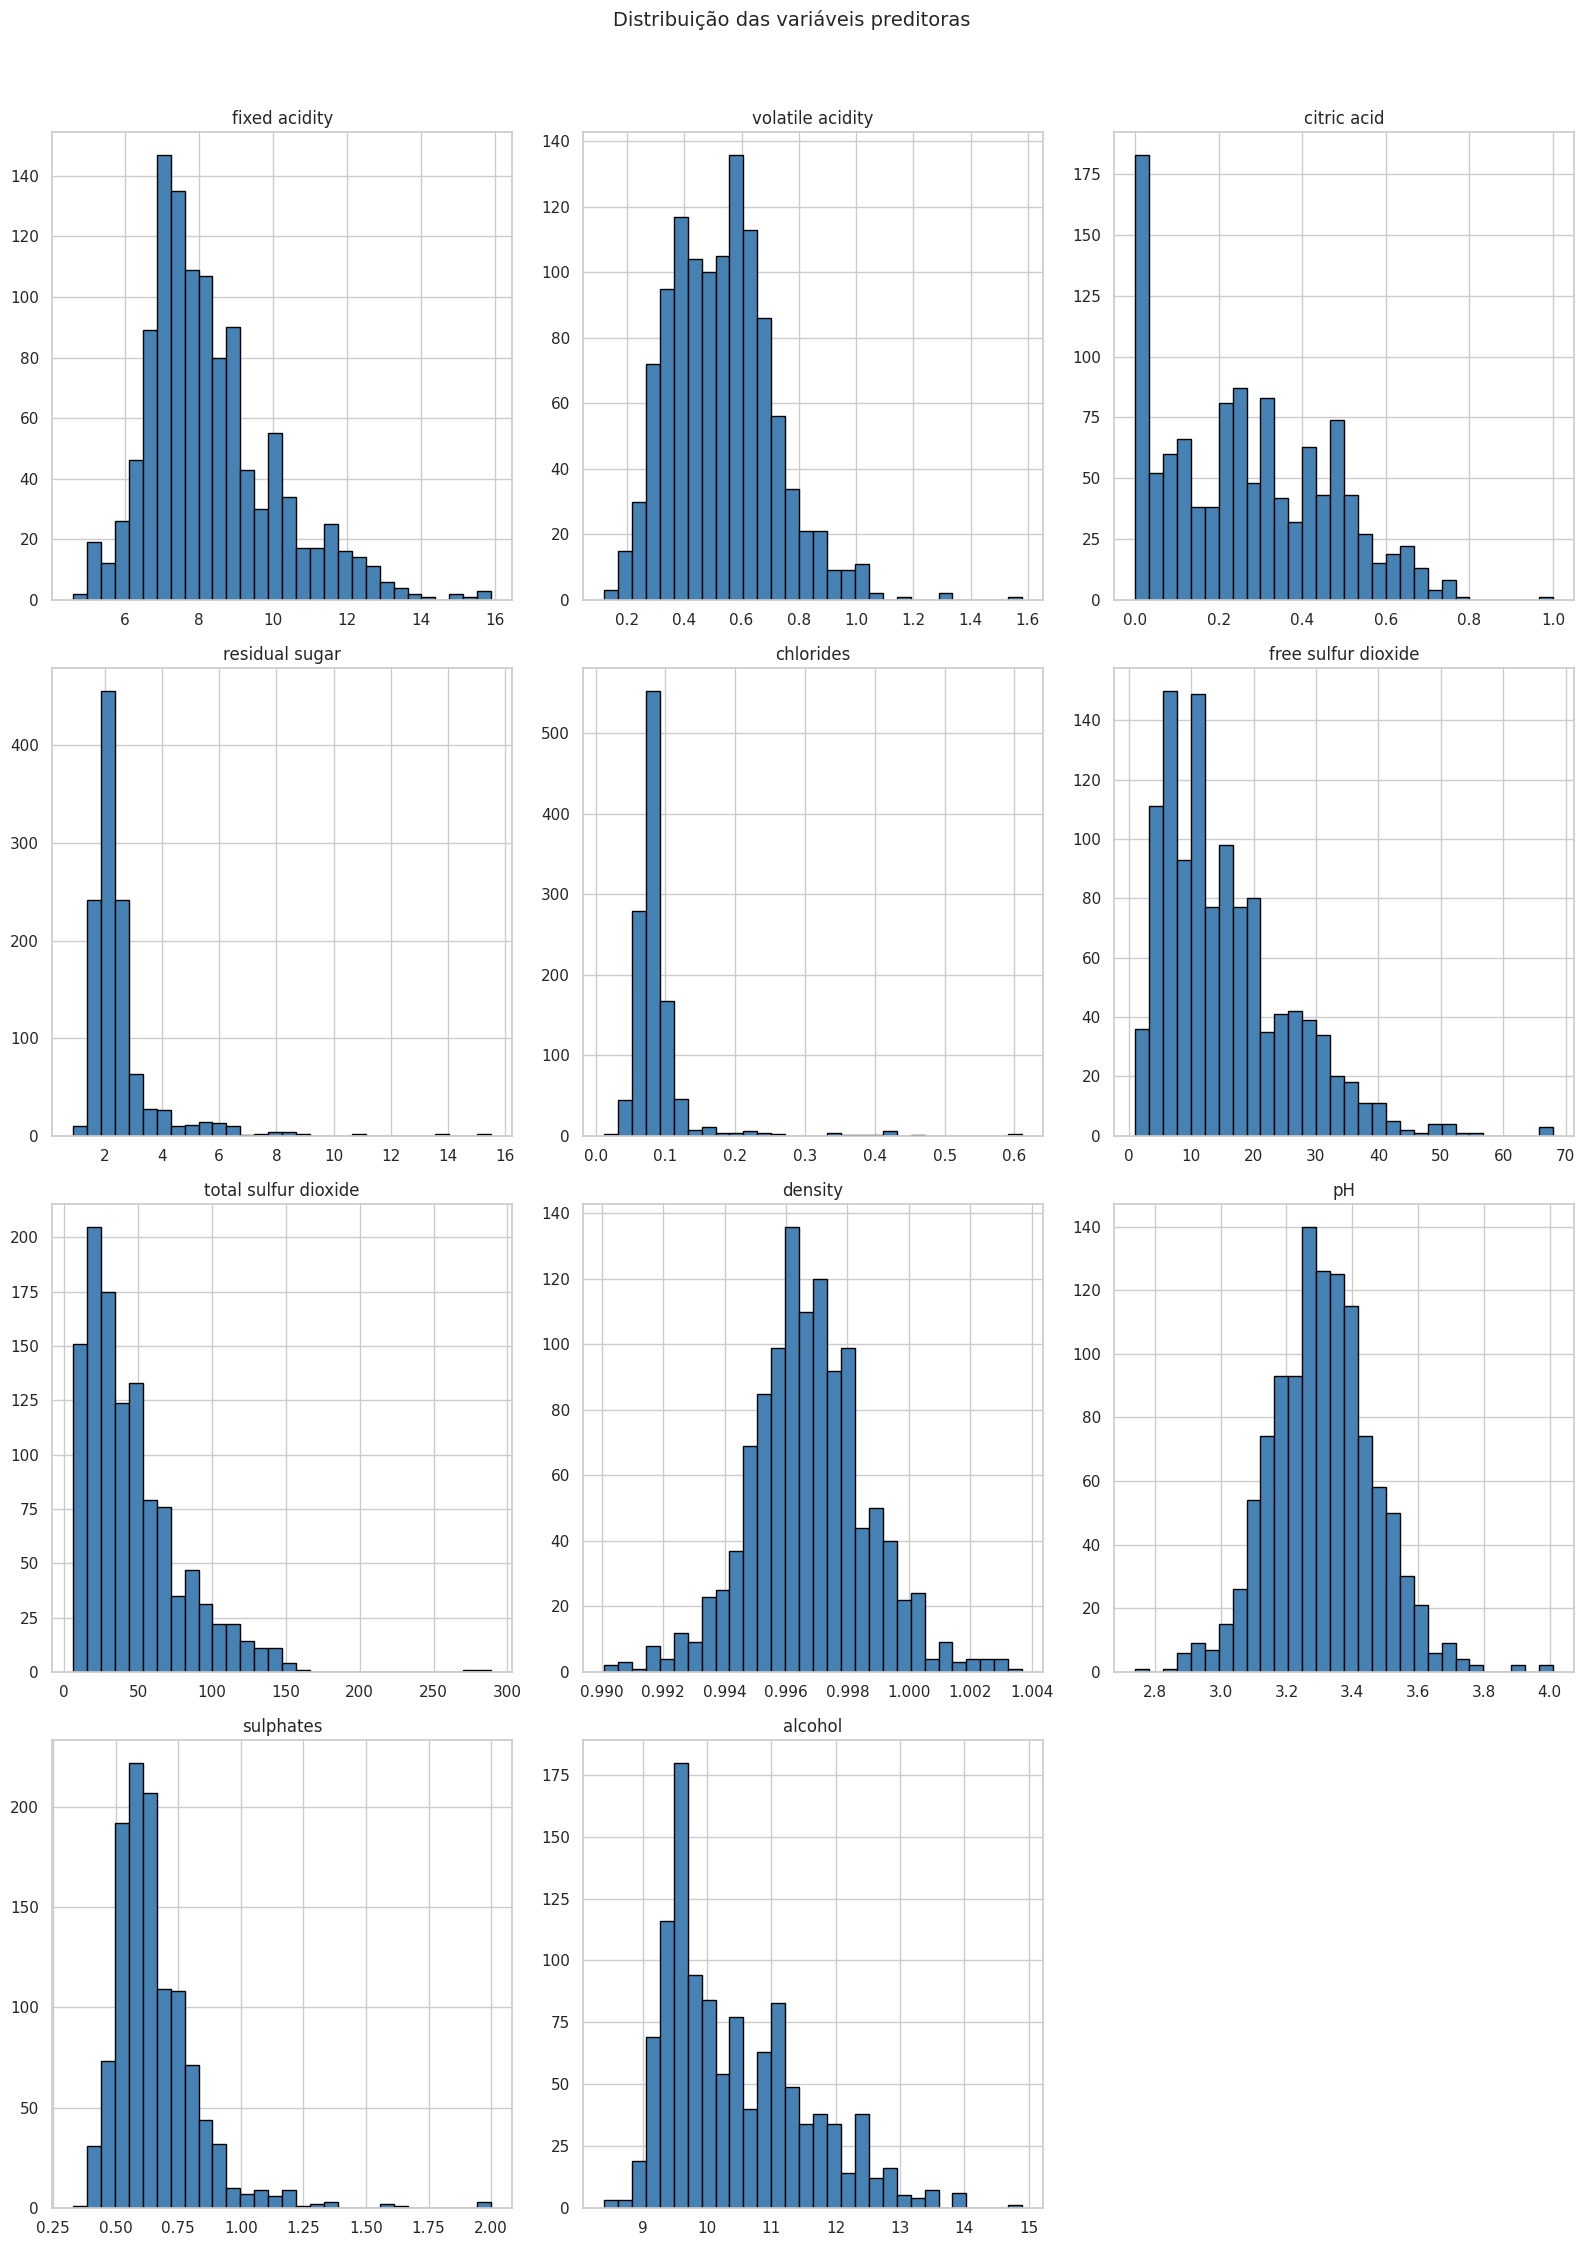

In [ ]:
#Cria uma lista com todas as colunas exceto 'quality' e 'high_quality'
#Variáveis preditoras (características do vinho)
features = [col for col in df.columns if col not in ["quality", "high_quality"]]

#Cria uma matriz de histogramas, um para cada feature
df[features].hist(bins=30, figsize=(16, 22), edgecolor="black", color="steelblue")

#Configurações visuais
plt.suptitle("Distribuição das variáveis preditoras", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**2.4 - Detecção de outliers**

<br>
Boxplots por classe para identificar valores atípicos e já comparar o comportamento de cada variável entre vinhos de alta e baixa/média qualidade.

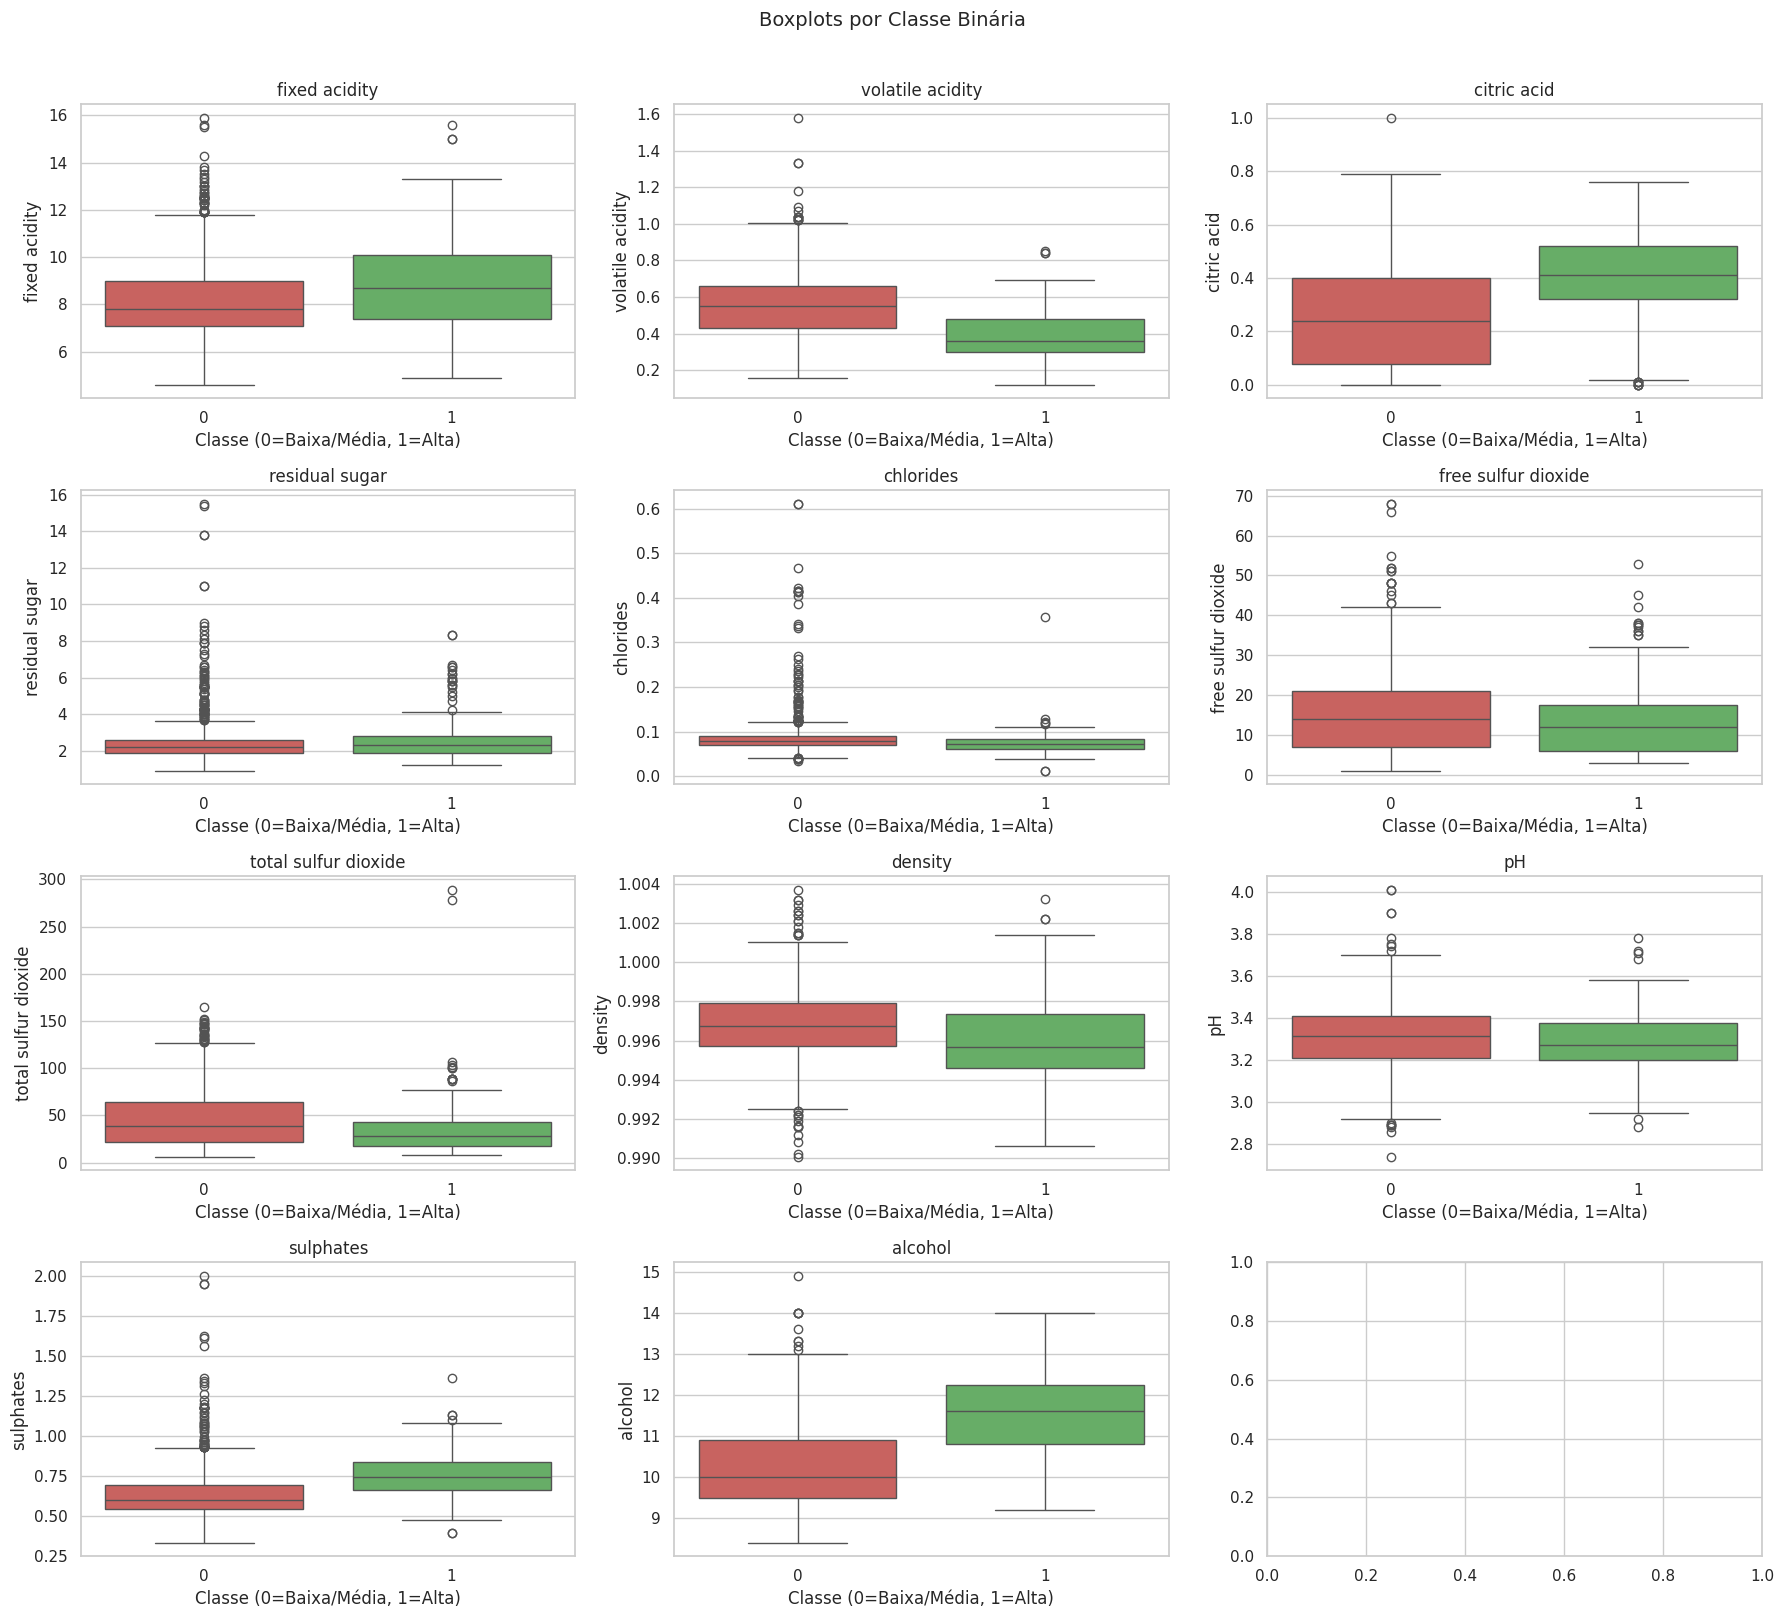

In [ ]:
# Cria uma figura com 4 linhas e 3 colunas (total de 12 subplots)
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

# Itera sobre cada feature e seu índice correspondente
for i, col in enumerate(features):
    sns.boxplot(data=df, x="high_quality", y=col, ax=axes[i],
                hue="high_quality", palette={0: "#d9534f", 1: "#5cb85c"}, legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Classe (0=Baixa/Média, 1=Alta)")

# Configurações visuais
plt.suptitle("Boxplots por Classe Binária", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**2.5 - Correlações**

<br>
O mapa de calor abaixo mostra a correlação de Pearson entre todas as variáveis numéricas, incluindo a variável alvo binária. Correlações altas como 'high_quality' indicam features potencialmente relevantes para o modelo.

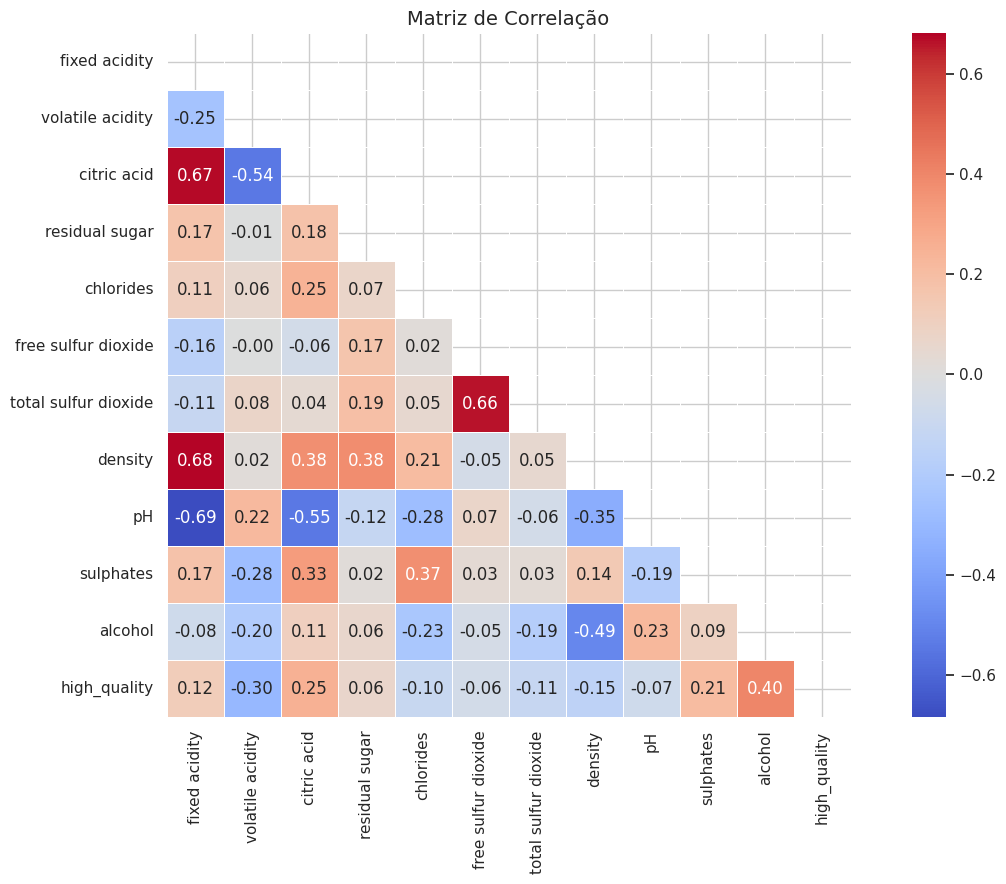

Correlação com high_quality (ordenada):
alcohol                 0.403676
citric acid             0.251146
sulphates               0.208020
fixed acidity           0.123212
residual sugar          0.064145
free sulfur dioxide    -0.055977
pH                     -0.073318
chlorides              -0.103985
total sulfur dioxide   -0.113373
density                -0.148670
volatile acidity       -0.304523
Name: high_quality, dtype: float64


In [ ]:
#Cálculo de correlação (Pearson) entre todas as features e a variável alvo
corr = df[features + ["high_quality"]].corr()

#Cálculo de correlação (Pearson) entre todas as features e a variável alvo
plt.figure(figsize=(13, 9))

#Cria uma máscara para esconder o triângulo superior da matriz (evita redundância)
mask = np.triu(np.ones_like(corr, dtype=bool))

# #Cria o mapa de calor
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

#Identifica as features mais correlacionados com a qualidade
print("Correlação com high_quality (ordenada):")
print(corr["high_quality"].drop("high_quality").sort_values(ascending=False))

**2.6 - Conclusões da EDA**

<br>


*   O dataset está completo (sem valores nulos), facilitando o pré-processamento.
*   As classes estão desbalanceadas (~85% vs ~15%), o que exigirá atenção na modelagem (uso de métricas como F1-score, ROC-AUC, ou técnicas como SMOTE).
*   'alcohol', 'volatible acidity', 'sulphates' e 'citric acid' são as variáveis com maiore correlação de qualidade - candidatas a features mais importantes.
*   'residual sugar', 'free sulfur dioxide' e 'total sulfur dioxide' apresentam outliers relevantes que deverão ser tratados no pré-processamento.
*   Existe correlação alta entre 'free sulfur dioxide' e 'total sulfur dioxide' (~0.67), o que pode indicar multicolinearidade a ser avaliada na etapa de modelagem.







**3 - PRÉ-PROCESSAMENTO DOS DADOS**

3.1 - Verificação e tratamento de missing values

O código verifica se existem valores nulos em todas as colunas do dataset. Para o WineQT, o resultado é que nenhum missing value foi encontrado — o dataset está completo com 1.143 linhas e 12 colunas. Caso houvesse valores faltantes, o código aplicaria imputação pela mediana, que é mais robusta que a média por não ser afetada por outliers.

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Quantidade': missing,
    'Percentual (%)': missing_pct
}).query('Quantidade > 0')

if missing_df.empty:
    print('Nenhum missing value encontrado!')
    print(f'Dataset completo: {df.shape[0]} linhas x {df.shape[1]} colunas')
else:
    print('Missing values encontrados:')
    print(missing_df)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    df[num_cols] = imputer.fit_transform(df[num_cols])
    print('Tratados com mediana.')

Nenhum missing value encontrado!
Dataset completo: 1143 linhas x 13 colunas


3.2 - Normalização ou padronização

Os imports do StandardScaler, train_test_split e SMOTE são carregados aqui para deixar tudo disponível nas etapas seguintes. A padronização em si é aplicada na etapa 3.5, após a separação treino/teste, para evitar data leakage — o scaler é fitado somente nos dados de treino e apenas transformado nos dados de teste.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

3.3 - Feature engineering (se fizer sentido)

Foram criadas 4 novas variáveis a partir das features originais, todas com justificativa química.

In [ ]:
df_clean = df.copy()

# Razão SO2 livre / total
df_clean['so2_ratio'] = (
    df_clean['free sulfur dioxide'] / (df_clean['total sulfur dioxide'] + 1e-6)
)

# Acidez total
df_clean['total_acidity'] = (
    df_clean['fixed acidity'] + df_clean['volatile acidity']
)

# Álcool / Densidade
df_clean['alcohol_density_ratio'] = (
    df_clean['alcohol'] / df_clean['density']
)

# Açúcar residual / Álcool
df_clean['sugar_alcohol_ratio'] = (
    df_clean['residual sugar'] / (df_clean['alcohol'] + 1e-6)
)

print('4 novas features criadas:')
print('  so2_ratio             -> SO2 livre / SO2 total')
print('  total_acidity         -> acidez fixa + volátil')
print('  alcohol_density_ratio -> álcool / densidade')
print('  sugar_alcohol_ratio   -> açúcar residual / álcool')
print(f'\nShape após feature engineering: {df_clean.shape}')

4 novas features criadas:
  so2_ratio             -> SO2 livre / SO2 total
  total_acidity         -> acidez fixa + volátil
  alcohol_density_ratio -> álcool / densidade
  sugar_alcohol_ratio   -> açúcar residual / álcool

Shape após feature engineering: (1143, 17)


3.4 - Separação treino/teste

O dataset foi dividido em 80% treino e 20% teste, resultando em:

Treino: ~914 amostras

Teste: ~229 amostras

O parâmetro stratify=y garante que a proporção de vinhos de alta e baixa qualidade seja mantida igual nos dois conjuntos, o que é fundamental dado o desbalanceamento de classes (~85% baixa vs ~15% alta qualidade).

In [ ]:
RANDOM_STATE = 42

FEATURES = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
    'so2_ratio', 'total_acidity', 'alcohol_density_ratio', 'sugar_alcohol_ratio'
]
TARGET = 'high_quality'

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Total de features : {len(FEATURES)}')
print(f'Treino            : {X_train.shape[0]:,} amostras')
print(f'Teste             : {X_test.shape[0]:,} amostras')
print()
print('Proporção no treino:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Proporção no teste:')
print(y_test.value_counts(normalize=True).round(3))

Total de features : 15
Treino            : 914 amostras
Teste             : 229 amostras

Proporção no treino:
high_quality
0    0.861
1    0.139
Name: proportion, dtype: float64

Proporção no teste:
high_quality
0    0.86
1    0.14
Name: proportion, dtype: float64


3.5 - Garantir que os dados estão prontos para modelagem

Três ações foram executadas em sequência:

***StandardScaler*** — todas as 15 features foram padronizadas para média ≈ 0 e desvio padrão ≈ 1. O scaler foi fitado somente no treino e aplicado no teste, evitando vazamento de informação.

***SMOTE*** — técnica de oversampling aplicada somente no treino para corrigir o desbalanceamento de classes (~6:1). Após o SMOTE, as duas classes ficam equilibradas, o que melhora a capacidade do modelo de aprender a identificar vinhos de alta qualidade.

***Salvamento dos arquivos*** — todos os dados processados foram exportados para a pasta data/processed/, incluindo os conjuntos de treino e teste, o dataset limpo e o scaler serializado com joblib, deixando tudo pronto para a Etapa 4 de Modelagem.


In [ ]:
# Padronização
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print('Estatísticas após padronização (treino):')
print(X_train_scaled.describe().loc[['mean','std']].round(3))
print()

# Balanceamento com SMOTE (somente no treino)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_final, y_train_final = smote.fit_resample(X_train_scaled, y_train)

print(f'Treino antes do SMOTE : {X_train_scaled.shape[0]:,} amostras')
print(f'Treino após SMOTE     : {X_train_final.shape[0]:,} amostras')
print()
print('Distribuição após SMOTE:')
print(pd.Series(y_train_final).value_counts())
print()

# Salvando arquivos
import joblib, os
os.makedirs('data/processed', exist_ok=True)

pd.DataFrame(X_train_final, columns=FEATURES).to_csv('data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('data/processed/X_test.csv', index=False)
pd.Series(y_train_final, name=TARGET).to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)
df_clean.to_csv('data/processed/wine_clean.csv', index=False)
joblib.dump(scaler, 'data/processed/scaler.pkl')

print('=' * 50)
print('     RESUMO DO PRÉ-PROCESSAMENTO')
print('=' * 50)
print(f'Amostras totais       : {len(df):,}')
print(f'Features originais    : 11')
print(f'Features engineered   : 4')
print(f'Total features        : {len(FEATURES)}')
print(f'Treino (após SMOTE)   : {len(X_train_final):,}')
print(f'Teste                 : {len(X_test_scaled):,}')
print(f'Padronização          : StandardScaler')
print(f'Balanceamento         : SMOTE (somente no treino)')
print('=' * 50)
print('Dados prontos para a Etapa 4 - Modelagem!')

Estatísticas após padronização (treino):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean         -0.000            -0.000       -0.000           0.000     -0.000   
std           1.001             1.001        1.001           1.001      1.001   

      free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  \
mean               -0.000                -0.000    0.000 -0.000      0.000   
std                 1.001                 1.001    1.001  1.001      1.001   

      alcohol  so2_ratio  total_acidity  alcohol_density_ratio  \
mean   -0.000      0.000          0.000                  0.000   
std     1.001      1.001          1.001                  1.001   

      sugar_alcohol_ratio  
mean               -0.000  
std                 1.001  

Treino antes do SMOTE : 914 amostras
Treino após SMOTE     : 1,574 amostras

Distribuição após SMOTE:
high_quality
0    787
1    787
Name: count, dtype: int64

     RESUMO DO PRÉ-PROCESSAMENTO
Amo

**4 - DESENVOLVIMENTO DO MODELO A - RANDOM FOREST**

 --- ETAPA 4: MODELAGEM (Random Forest) ---

Bloco 1: Importações e Configurações

In [ ]:
# Modelagem, avaliação e baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score)
import joblib, json, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('results', exist_ok=True)   # pasta exigida no edital

Bloco 2: Treinamento do Modelo (Random Forest)

In [ ]:
# 1. Modelo base — SEM class_weight: o SMOTE no pré-processamento já balanceou o treino.

rf = RandomForestClassifier(random_state=42)

# 2. Grid de hiperparâmetros (ajuste básico)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 3. GridSearchCV — scoring='f1' por causa do desbalanceamento;
#    cv=5 já é estratificado automaticamente para classificadores
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Iniciando treinamento com GridSearchCV...")
grid_search.fit(X_train_final, y_train_final)

best_model = grid_search.best_estimator_
print(f"\nMelhores parâmetros: {grid_search.best_params_}")

Iniciando treinamento com GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Melhores parâmetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


Bloco 3: Avaliação do Modelo


Matriz de Confusão:


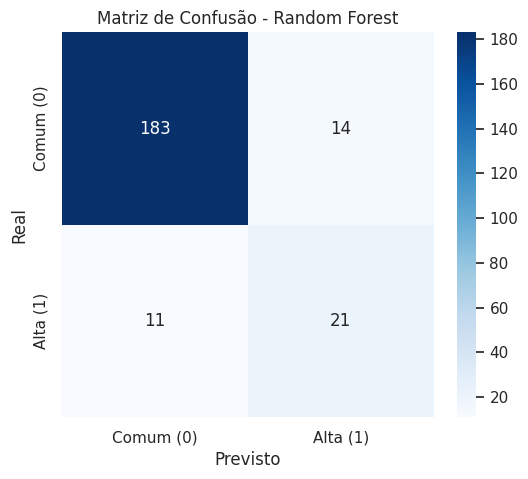


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       197
           1       0.60      0.66      0.63        32

    accuracy                           0.89       229
   macro avg       0.77      0.79      0.78       229
weighted avg       0.90      0.89      0.89       229



In [ ]:
# Predição no TESTE (nunca tocado pelo SMOTE)
y_pred = best_model.predict(X_test_scaled)

# Matriz de Confusão
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Comum (0)', 'Alta (1)'],
            yticklabels=['Comum (0)', 'Alta (1)'])
plt.title("Matriz de Confusão - Random Forest")
plt.ylabel("Real"); plt.xlabel("Previsto")
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()

# Relatório de classificação (acurácia, precisão, recall, F1)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Bloco 4: Interpretação e Salvamento

In [ ]:
# Baseline 1: chuta sempre a classe majoritária (mostra a armadilha da acurácia)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_final, y_train_final)
y_dummy = dummy.predict(X_test_scaled)

# Baseline 2: Regressão Logística (baseline "de verdade")
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_final, y_train_final)
y_logreg = logreg.predict(X_test_scaled)

# ROC-AUC do Random Forest
rf_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])

print("Comparação — F1 da classe 1 (alta qualidade):")
print(f"  Dummy (mais frequente) : {f1_score(y_test, y_dummy):.3f}")
print(f"  Regressão Logística    : {f1_score(y_test, y_logreg):.3f}")
print(f"  Random Forest          : {f1_score(y_test, y_pred):.3f}   <- seu modelo")
print(f"\nROC-AUC (Random Forest): {rf_auc:.3f}")

Comparação — F1 da classe 1 (alta qualidade):
  Dummy (mais frequente) : 0.000
  Regressão Logística    : 0.483
  Random Forest          : 0.627   <- seu modelo

ROC-AUC (Random Forest): 0.918


Bloco 5 — Salvar Métricas

In [ ]:
report = classification_report(y_test, y_pred, output_dict=True)
metricas = {
    "modelo": "RandomForest",
    "melhores_params": grid_search.best_params_,
    "accuracy": round(report["accuracy"], 3),
    "precision_classe1": round(report["1"]["precision"], 3),
    "recall_classe1": round(report["1"]["recall"], 3),
    "f1_classe1": round(report["1"]["f1-score"], 3),
    "roc_auc": round(rf_auc, 3),
    "baselines_f1": {
        "dummy": round(f1_score(y_test, y_dummy), 3),
        "logistic_regression": round(f1_score(y_test, y_logreg), 3),
    },
}
with open("results/metrics_rf.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print("Métricas salvas em results/metrics_rf.json")
print(json.dumps(metricas, indent=2, ensure_ascii=False))

Métricas salvas em results/metrics_rf.json
{
  "modelo": "RandomForest",
  "melhores_params": {
    "max_depth": 20,
    "min_samples_split": 2,
    "n_estimators": 100
  },
  "accuracy": 0.891,
  "precision_classe1": 0.6,
  "recall_classe1": 0.656,
  "f1_classe1": 0.627,
  "roc_auc": 0.918,
  "baselines_f1": {
    "dummy": 0.0,
    "logistic_regression": 0.483
  }
}


Bloco 6 — Interpretação e Salvamento

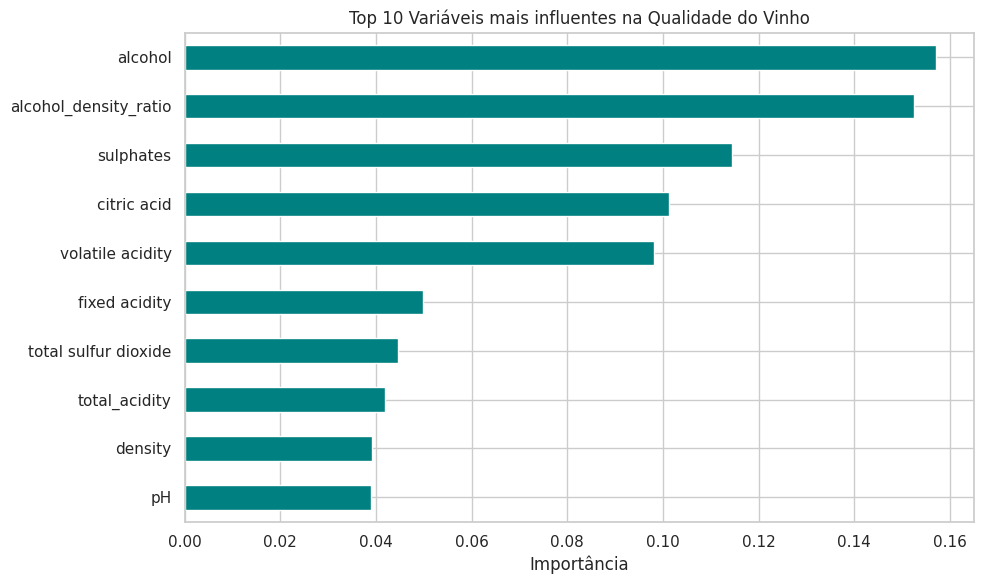


Modelo salvo em 'results/modelo_rf_v1.pkl'


In [ ]:
# 1. Feature Importance (o que mais influencia a qualidade — Etapa 6)
feature_importances = pd.Series(best_model.feature_importances_, index=FEATURES)
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variáveis mais influentes na Qualidade do Vinho')
plt.xlabel('Importância')
plt.gca().invert_yaxis()       # maior no topo (mais legível)
plt.tight_layout()
plt.savefig('results/feature_importance.png', bbox_inches='tight')
plt.show()


joblib.dump(best_model, 'results/modelo_rf_v1.pkl')
print("\nModelo salvo em 'results/modelo_rf_v1.pkl'")

**5 - DESENVOLVIMENTO DO MODELO B - XGBoost**

**5.1 - Modelo B** <br><br>
O segundo modelo escolhido para o desafio é o **XGBoost** (Extreme Gradient Boosting), um algoritmo baseado em boosting que constrói árvores de decisão de forma sequencial - cada nova árvore aprende com os erros da anterior. Diferente do Random Forest, que treina árvores em paralelo de forma independente, o XGBoost otimiza uma função de perda de maneira iterativa, o que tende a gerar modelos mais precisos em dados tabulares. <br><br>
Para otimização de hiperparâmetros, será utilizado o GridSearchCV com validação cruzada estratificada, garantindo que a proporção das classes seja mantida em cada fold, essencial dado o desbalanceamento do dataset.

In [ ]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import pickle
import os
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

#Cria pasta para resultados
os.makedirs("results", exist_ok=True)

#Carrega e prepara os dados
df = pd.read_csv("/content/WineQT.csv").drop(columns=["Id"])
df["quality_label"] = (df["quality"] >= 7).astype(int)

#Separa variáveis preditoras e alvo
X = df.drop(columns=["quality", "quality_label"])
Y = df["quality_label"]

#Divide em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

#Mostra as informações sobre os dados
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Proporção da classe 1 no treino: {Y_train.mean():.2%}")
print(f"Proporção da classe 1 no teste: {Y_test.mean():.2%}")


Treino: (914, 11) | Teste: (229, 11)
Proporção da classe 1 no treino: 13.89%
Proporção da classe 1 no teste: 13.97%


**5.2 - Tratamento do desbalanceamento de classes** <br><br>
Como observado na EDA, o dataset é desbalanceado: vinhos de alta qualidade (classe 1) representam uma minoria das amostras. Se ignorado, o modelo tende a favorecer a classe majoritária, prejudicando a detecção dos vinhos de alta qualidade. <br><br>
No Random Forest (Modelo A), isso foi tratada com o parâmetro `class_weight='balanced'`. o XGBoost oferece um mecanismo equivalente: o parâmetro `scale_pos_weight`, definido como a razão entre o número de amostras negativas e positivas no conjunto de treino. Quanto maior esse valor, mais peso o modelo atribui aos erros na classe minoritária durante o treinamento.

In [ ]:
#Conta quantos exemplos de cada classe existem no treino
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()

#Calcula a razão entre as classes
spw = round(neg / pos, 2)

#Mostra os resultados
print(f"Classe 0 (Baixa/Média): {neg}")
print(f"Classe 1 (Alta): {pos}")
print(f"scale_pos_weight: {spw}")

Classe 0 (Baixa/Média): 787
Classe 1 (Alta): 127
scale_pos_weight: 6.2


**5.3 - Busca de hiperparâmetros com GridSearchCV** <br><br>

O GridSearchCV testa sistematicamente todas as combinações de hiperparâmetros definidas na tabela abaixo, avaliando cada uma com validação cruzada estratificada de 5 folds. A métrica de seleção é o F1-score, a mesma utilizada no Modelo A, o que garante uma comparação justa entre os dois odelos ao final.<br><br>
Os hiperparâmetros explorados são:<br><br>
| Parâmetro | Descrição |
|---|---|
| `n_estimators` | Número de árvores (rodadas de boosting) |
| `max_depth` | Profundidade máxima de cada árvore |
| `learning_rate` | Taxa de aprendizado — controla a contribuição de cada árvore |
| `subsample` | Fração das amostras usadas em cada árvore (evita overfitting) |
| `colsample_bytree` | Fração das features usadas em cada árvore (evita overfitting) |




In [ ]:
#Define o grid de hiperparâmetros a serem testados
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

#Cria o modelo base XGBoost
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

#Define a validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Configura o grid search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

#Executa o treinamento
grid_search.fit(X_train, Y_train)

#Mostra os melhores resultados
print("\nMelhores hiperparâmetros encontrados:")
print(grid_search.best_params_)
print(f"\nMelhor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:27:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Melhores hiperparâmetros encontrados:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Melhor F1 (CV): 0.6306


**5.4 - Avaliação no conjunto de teste**<br><br>
Com o melhor modelo selecionado pelo GridSearchCV, realizamos a avaliação final no conjunto de testes, dados que o modelo nunca viu durante o treinamento. As métricas calculadas são:<br>

*   Accuracy: proporção geral de acertos
*   Precision: dos vinhos classificados como alta qualidade, quantos realmente são
*   Recall: dos vinhos que realmente são de alta qualidade, quantos o modelo identificou corretamente
*   F1-score: média harmônica entre Precision e Recall - métrica principal dado o desbalanceamento
*   ROC-AUC: capacidade geral do modelo de separar as classes, independente do thresold<br><br>

As métricas são salvas em `results/` para uso na etapa de comparação dos modelos.







In [ ]:
#Pega o melhor modelo encontrado pelo grid search
best_xgb = grid_search.best_estimator_

#Faz previsões no conjunto de teste
Y_pred = best_xgb.predict(X_test)
Y_proba = best_xgb.predict_proba(X_test)[:, 1]

#Calcula as métricas de desempenho
metrics_b = {
    "modelo": "XGBoost",
    "accuracy": accuracy_score(Y_test, Y_pred),
    "precision": precision_score(Y_test, Y_pred),
    "recall": recall_score(Y_test, Y_test),
    "f1": f1_score(Y_test, Y_pred),
    "roc_auc": roc_auc_score(Y_test, Y_proba),
}

#Exibe as métricas
print("Métricas - Modelo B (XGBoost)")
for k, v in metrics_b.items():
  if k != "modelo":
    print(f" {k:12s}: {v:.4f}")

#Exibe o relatório completo por classe
print("/nRelatório completo:")
print(classification_report(Y_test, Y_pred, target_names=["Baixa/média", "Alta"]))

#Salva as métricas em um arquivo CSV
pd.DataFrame([metrics_b]).to_csv("results/metrics_xgboost.csv", index=False)

Métricas - Modelo B (XGBoost)
 accuracy    : 0.8996
 precision   : 0.6452
 recall      : 1.0000
 f1          : 0.6349
 roc_auc     : 0.9055
/nRelatório completo:
              precision    recall  f1-score   support

 Baixa/média       0.94      0.94      0.94       197
        Alta       0.65      0.62      0.63        32

    accuracy                           0.90       229
   macro avg       0.79      0.78      0.79       229
weighted avg       0.90      0.90      0.90       229



**5.5 - Visualização: Matriz de confusão e curva ROC**<br><br>

A matriz de confusão mostra em detalhes os acertos e erros por classe, permitindo identificar se o modelo erra mais ao classficar vinhos bons como ruins (falsos negativos) ou ruins como bons (falsos positivos). <br><br>

A curva ROC ilustra o trade-off entre a taxa de verdadeiros positivos e falsos positivos em diferentes thresholds de decisão. Quanto mais a curva se aproxima do canto superior esquerdo, melhor o poder discriminativo do modelo. A área sob a curva (AUC) resume isso em um único número e quanto mais próximo de 1, melhor.

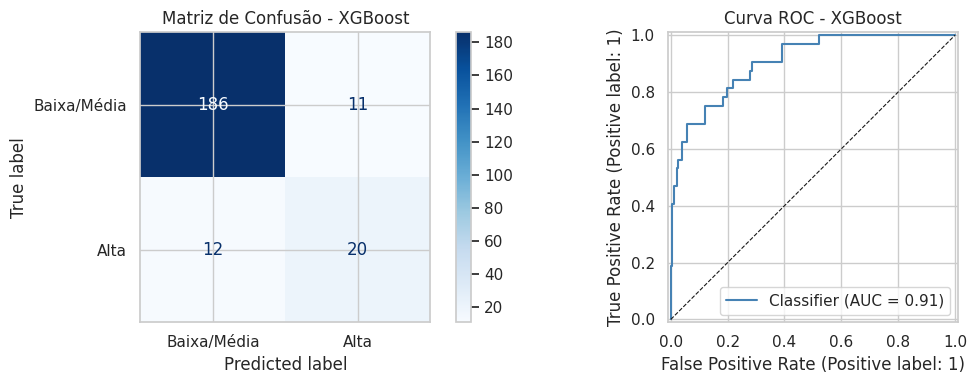

In [ ]:
#Cria uma figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Cria a matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    Y_test, Y_pred,
    display_labels=["Baixa/Média", "Alta"],
    cmap="Blues", ax=axes[0]
)

axes[0].set_title("Matriz de Confusão - XGBoost")

#Cria a curva ROC
RocCurveDisplay.from_predictions(Y_test, Y_proba, ax=axes[1], color="steelblue")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_title("Curva ROC - XGBoost")

#Ajusta, salva e exibe o gráfico
plt.tight_layout()
plt.savefig("results/avaliacao_xgboost.png", bbox_inches="tight")
plt.show()

**5.6 - Feature Importance**<br><br>

O XGBoost permite extrair a importância de cada variável para as predições do modelos. Aqui utilizamos a métrica 'gain' (ganho médio de cada feature nas divisões das árvores): quanto maior o valor, mais aquela variável contribuiu para reduzir o erro do modelo. <br><br>

Essa análise será aproveitada na etapa final do desafio (Interpretação dos Resultados), onde as variáveis mais relevantes serão discutidas em termos de suas implicações parar o processo de produção do vinho.

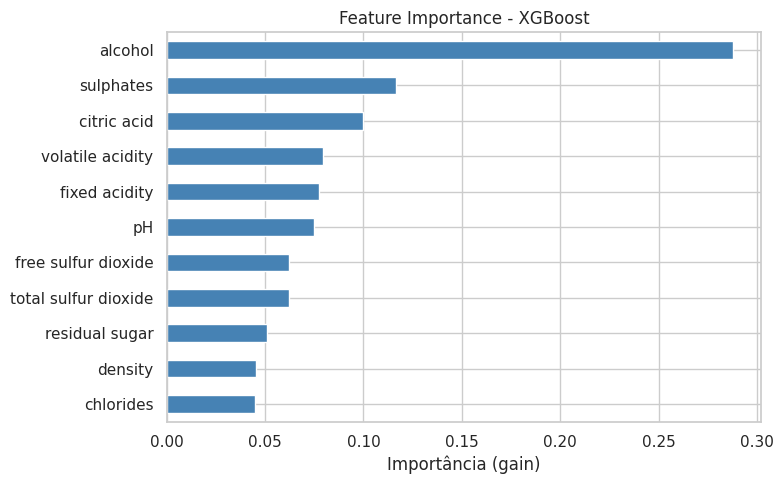

alcohol                 0.287675
sulphates               0.116315
citric acid             0.099634
volatile acidity        0.079249
fixed acidity           0.077326
pH                      0.074639
free sulfur dioxide     0.062271
total sulfur dioxide    0.061951
residual sugar          0.051041
density                 0.045230
chlorides               0.044668
dtype: float32


In [ ]:
#Extrai e organiza as importâncias da features
importances = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

#Cria o gráfico de barras horizontais
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importância (gain)")
plt.tight_layout()
plt.savefig("results/feature_importance_xgboost.png", bbox_inches="tight")
plt.show()

#Exibe a lista completa de importâncias
print(importances.sort_values(ascending=False))

**5.7 - Salvando o modelo treinado**<br><br>

O modelo final é serializado com `pickle` e salvo em `results/`, seguindo o mesmo padrão adotado para o Modelo A. Isso garante que o modelo possa ser carregado futuramente para novas previsões sem necessidade de re-treinamento.

In [ ]:
with open("results/modelo_xgboost.pkl", "wb") as f:
  pickle.dump(best_xgb, f)

print("Modelo salvo em results/modelo_xgboost.pkl")

Modelo salvo em results/modelo_xgboost.pkl


**6 - COMPARAÇÃO ENTRE MODELOS**

**6.1 - Avaliação e comparação dos modelos** <br><br>

Com ambos os modelos treinados e valaidos no mesmo conjutno de teste, é possível realizar uma comparação direta entre o modelo A (Random Forest) e o modelo B(XGBoost). Vale destacar que os modelos foram desenvolvidos com pipelines ligeiramente diferentes: o Random Forest utilizou o SMOTE para balancear o treino, enquanto o XGBoost tratou o desbalanceamento via scale_pos_weight. Ambas são abordagens válidas e amplamente utilizadas na literatura.

In [ ]:
#importações de bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Tabela comparativa entre métricas
comparacao = pd.DataFrame([
    {
      "Modelo": "Random Forest",
      "Accuracy": 0.891,
      "Precision": 0.600,
      "Recall": 0.656,
      "F1-score": 0.627,
      "ROC-AUC": 0.918,
    },
    {
        "Modelo": "XGBoost",
        "Accuracy": 0.900,
        "Precision": 0.629,
        "Recall": 0.688,
        "F1-score": 0.657,
        "ROC-AUC": 0.900,
    },
]).set_index("Modelo")

display(comparacao.style
        .format("{:.3f}")
        .highlight_max(axis=0, color="#d4edda")
        .set_caption("Comparação de Métricas - Conjunto de Teste")
)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Random Forest,0.891,0.600,0.656,0.627,0.918
XGBoost,0.900,0.629,0.688,0.657,0.900


**6.2 - Visualização das métricas**<br><br>

O gráfico abaixo facilita a comparação visual entre os dois modelos em todas as métricas avaliadas.

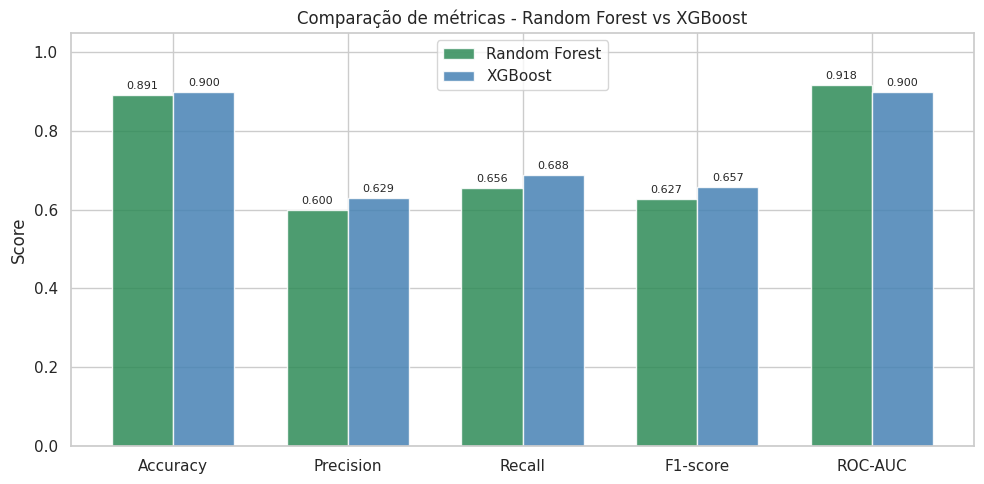

In [ ]:
metricas = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
rf_vals  = [0.891, 0.600, 0.656, 0.627, 0.918]
xgb_vals = [0.900, 0.629, 0.688, 0.657, 0.900]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_rf = ax.bar(x - width/2, rf_vals, width, label="Random Forest", color="#2e8b57", alpha=0.85)
bars_xgb = ax.bar(x + width/2, xgb_vals, width, label="XGBoost", color="#4682b4", alpha=0.85)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel("Score")
ax.set_title("Comparação de métricas - Random Forest vs XGBoost")
ax.legend()
ax.bar_label(bars_rf, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(bars_xgb, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("results/comparacao_modelos.png", bbox_inches="tight")
plt.show()

**6.3 - Análise e conclusão**<br><br>

**Desempenho geral**<br>
Ambos os modelos superam com folga os baselines estabelecidos (Dummy F1 = 0.000 e Regressão Logística F1 = 0.483), confirmando que as variáveis físico-químicas do vinho carregam informação preditiva real. <br><br>

**Comparação métrica a métrica**<br>
| Métrica | Vencedor | Diferença |
|---|---|---|
| Accuracy | XGBoost | +0.9 p.p. |
| Precision | XGBoost | +2.9 p.p. |
| Recall | XGBoost | +3.2 p.p. |
| F1-score | XGBoost | +3.0 p.p. |
| ROC-AUC | Random Forest | +1.8 p.p. |

<br>

O XGBoost apresentou um desempenho ligereiramente superior na maioria das métricas voltadas à classe minoritária (Alta Qualidade), que é justamente o foco do problema. O Random Forest, por outro lado, obteve ROC-AUC marginalmente mais alto (0.918 vs 0.900), indicando melhor capacidade de separação geral entre as classes em diferentes thresolds.<br><br>

**Matriz de confusão**<br>
Analisando as matrizes de confusão, os modelos têm comportamento muito similar:<br>
*   Random Forest: 21 verdadeiros positivos, 11 falsos negativos
*   XGBoost: 22 verdadeiros positivos, 10 falsos negativos<br>

O XGBoost erra um vinho de alta qualidade a menos - relevante no contexto do problema, onde classificar um vinho bom como ruim (falso negativo) é um erro mais custoso do que o inverso. <br><br>

**Conclusão**<br>
Para o objetivo deste desafio: identificar vinhos de alta qualidade a partir de características físico-químicas, o XGBoost se mostrou o modelo mais adequado, com melhor F1-score (0.657 vs 0.627) e recall (0.688 vs 0.656) na classe de interesse. A diferença é consistente em todas as métricas da classe 1, e o modelo foi alcançado sem a necessidade de oversampling sintético (SMOTE), apenas com o ajuste de peso via `scale_pos_weight`. <br>
Ambos os modelos são robustos e produtivos para uso em produção, sendo o XGBoost a recomendação final com base nos resultados obtivos.



**INTERPRETAÇÃO**

7 - INTERPRETAÇÃO DOS RESULTADOS

7.1 - Identificação das variáveis mais importantes para a qualidade do vinho


Para identificar as variáveis mais importantes de forma robusta, combinamos as evidências dos dois modelos treinados. Cada modelo calcula a importância de forma diferente (o Random Forest pela redução média de impureza; o XGBoost pelo ganho médio nas divisões), então normalizamos as importâncias de cada modelo (máximo = 1) e calculamos a média entre eles. Uma variável só aparece no topo se for relevante para ambos os modelos — o que reduz o risco de conclusões enviesadas por um único algoritmo.


Como o Modelo A foi treinado com 4 features engineered adicionais, a comparação é feita sobre as 11 variáveis físico-químicas originais, presentes nos dois modelos.

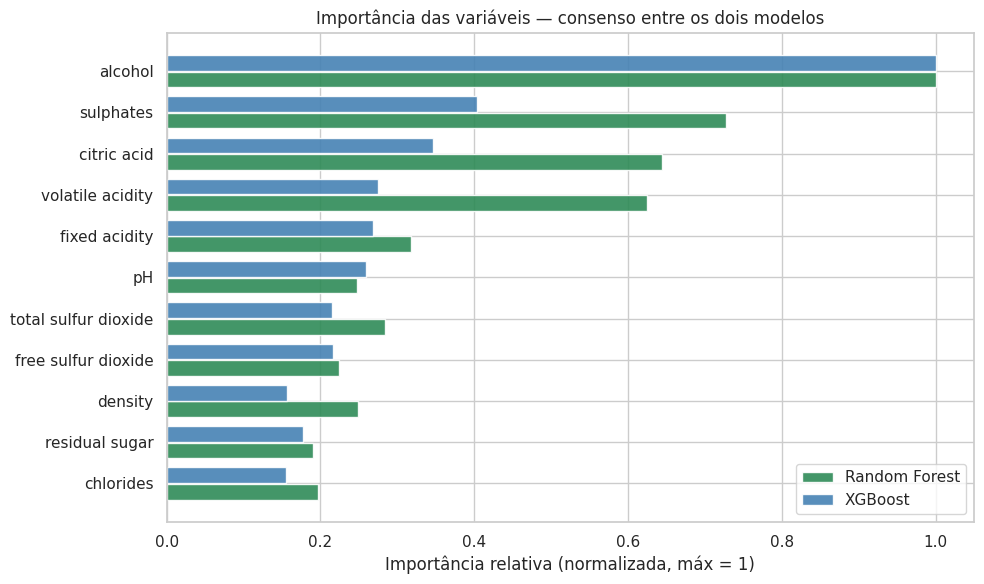

Ranking de importância (consenso entre RF e XGBoost):
alcohol                 1.000
sulphates               0.566
citric acid             0.496
volatile acidity        0.450
fixed acidity           0.293
pH                      0.254
total sulfur dioxide    0.250
free sulfur dioxide     0.221
density                 0.203
residual sugar          0.184
chlorides               0.176
Name: Consenso (média), dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importâncias do Modelo A (Random Forest) — treinado com 15 features
imp_rf_full = pd.Series(best_model.feature_importances_, index=FEATURES)

# Importâncias do Modelo B (XGBoost) — treinado com as 11 features originais
imp_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns)

# Restringe o RF às 11 features originais (comuns aos dois modelos)
imp_rf = imp_rf_full[imp_xgb.index]

# Normaliza (máximo = 1) e calcula o consenso (média entre os modelos)
ranking = pd.DataFrame({
    "Random Forest": imp_rf / imp_rf.max(),
    "XGBoost": imp_xgb / imp_xgb.max(),
})
ranking["Consenso (média)"] = ranking.mean(axis=1)
ranking = ranking.sort_values("Consenso (média)", ascending=True)

# Gráfico comparativo das importâncias
fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(ranking))
ax.barh(ypos - 0.2, ranking["Random Forest"], height=0.38,
        label="Random Forest", color="#2e8b57", alpha=0.9)
ax.barh(ypos + 0.2, ranking["XGBoost"], height=0.38,
        label="XGBoost", color="#4682b4", alpha=0.9)
ax.set_yticks(ypos)
ax.set_yticklabels(ranking.index)
ax.set_xlabel("Importância relativa (normalizada, máx = 1)")
ax.set_title("Importância das variáveis — consenso entre os dois modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/importancia_consenso.png", bbox_inches="tight")
plt.show()

# Ranking final
print("Ranking de importância (consenso entre RF e XGBoost):")
print(ranking["Consenso (média)"].sort_values(ascending=False).round(3))

**Leitura do ranking** <br><br>

Os dois modelos, apesar de arquiteturas e pipelines diferentes, convergem para o mesmo grupo de variáveis dominantes: <br>

| # | Variável | Efeito sobre a qualidade | Interpretação química |
|---|---|---|---|
| 1 | **alcohol** | Positivo (forte) | Maior teor alcoólico indica uvas mais maduras e fermentação completa — corpo e estrutura ao vinho. |
| 2 | **sulphates** | Positivo | Ação antioxidante e antimicrobiana; protege o vinho da deterioração e preserva aroma. |
| 3 | **citric acid** | Positivo | Contribui com frescor e "vivacidade"; vinhos de alta qualidade têm ~57% mais ácido cítrico em média. |
| 4 | **volatile acidity** | Negativo (forte) | Em excesso remete a vinagre (ácido acético) — defeito sensorial clássico. Vinhos de alta qualidade têm ~29% menos. |

<br>

O **álcool** é isoladamente a variável mais importante nos dois modelos (importância normalizada = 1.00 em ambos), seguido por **sulphates**, **citric acid** e **volatile acidity**. Essas quatro variáveis também foram as de maior correlação com a classe na EDA (seção 2.5), o que confirma a consistência entre a análise exploratória e a modelagem. <br><br>

Vale notar que, no Modelo A, a feature engineered `alcohol_density_ratio` aparece em 2º lugar entre as 15 features — reforçando o papel central do álcool, já que essa variável é derivada dele.

**7.2 - Gráficos finais comparativos** <br><br>

Os gráficos abaixo traduzem o ranking de importância em comparações diretas entre as classes, mostrando **como** as variáveis mais importantes se comportam em vinhos comuns vs. de alta qualidade.

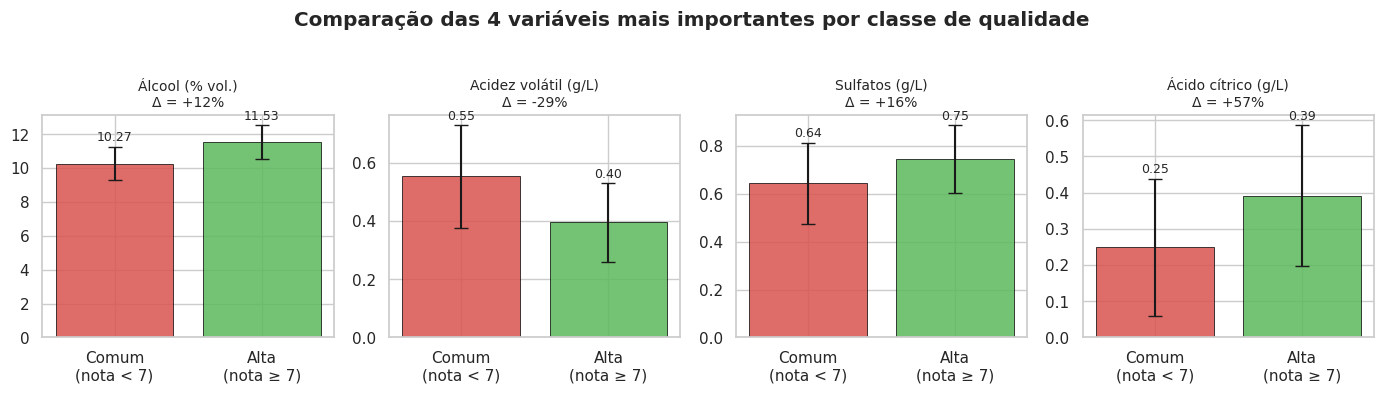

In [ ]:
# Gráfico 1 — Média (± desvio padrão) das 4 variáveis mais importantes, por classe
top4 = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
titulos = {"alcohol": "Álcool (% vol.)",
           "volatile acidity": "Acidez volátil (g/L)",
           "sulphates": "Sulfatos (g/L)",
           "citric acid": "Ácido cítrico (g/L)"}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, col in zip(axes, top4):
    medias = df.groupby("quality_label")[col].mean()
    desvios = df.groupby("quality_label")[col].std()
    barras = ax.bar(["Comum\n(nota < 7)", "Alta\n(nota ≥ 7)"], medias.values,
                    yerr=desvios.values, capsize=5,
                    color=["#d9534f", "#5cb85c"], alpha=0.85,
                    edgecolor="black", linewidth=0.6)
    diff = (medias[1] - medias[0]) / medias[0] * 100
    ax.set_title(f"{titulos[col]}\nΔ = {diff:+.0f}%", fontsize=10)
    ax.bar_label(barras, fmt="%.2f", padding=2, fontsize=9)

fig.suptitle("Comparação das 4 variáveis mais importantes por classe de qualidade",
             fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("results/top4_por_classe.png", bbox_inches="tight")
plt.show()

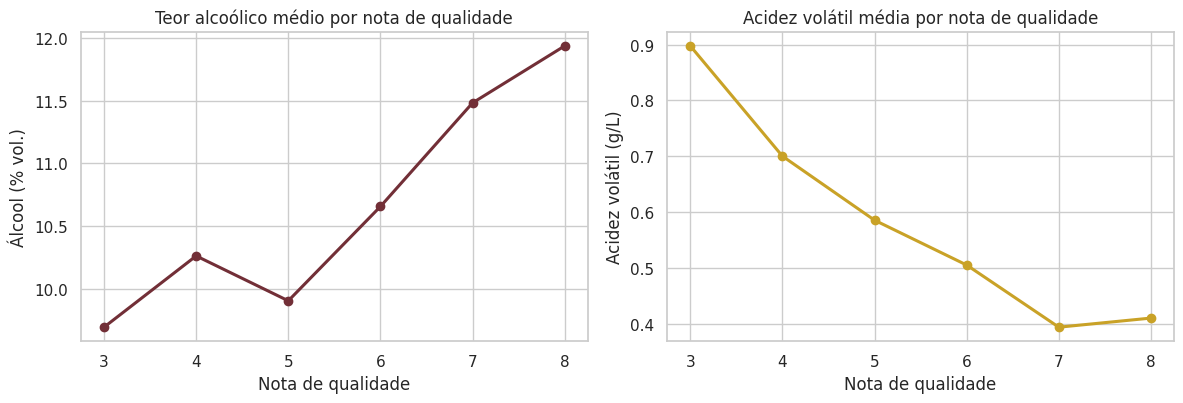

In [ ]:
# Gráfico 2 — Tendência das duas variáveis dominantes ao longo da escala de qualidade
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

media_alcool = df.groupby("quality")["alcohol"].mean()
axes[0].plot(media_alcool.index, media_alcool.values, marker="o",
             color="#722F37", linewidth=2.2)
axes[0].set_title("Teor alcoólico médio por nota de qualidade")
axes[0].set_xlabel("Nota de qualidade")
axes[0].set_ylabel("Álcool (% vol.)")

media_va = df.groupby("quality")["volatile acidity"].mean()
axes[1].plot(media_va.index, media_va.values, marker="o",
             color="#C9A227", linewidth=2.2)
axes[1].set_title("Acidez volátil média por nota de qualidade")
axes[1].set_xlabel("Nota de qualidade")
axes[1].set_ylabel("Acidez volátil (g/L)")

plt.tight_layout()
plt.savefig("results/tendencia_qualidade.png", bbox_inches="tight")
plt.show()

**Leitura dos gráficos** <br>

*   **Álcool**: vinhos de alta qualidade têm em média **11,5% vol.** contra **10,3% vol.** dos comuns (+12%). A tendência é praticamente monotônica: da nota 5 em diante, cada ponto adicional de qualidade acompanha um aumento no teor alcoólico médio.
*   **Acidez volátil**: comportamento espelhado — cai de forma consistente conforme a nota sobe (−29% na classe alta). É o principal "marcador de defeito" do dataset.
*   **Sulfatos** (+16%) e **ácido cítrico** (+57%): ambos maiores nos vinhos de alta qualidade, coerente com seus papéis de conservação e frescor.

<br>Esses quatro indicadores, em conjunto, formam um "perfil químico" claro do vinho de alta qualidade: **mais álcool, mais sulfatos, mais ácido cítrico e menos acidez volátil**.

**7.3 - Conclusão do trabalho** <br><br>
O trabalho abordou a previsão de qualidade de vinhos tintos a partir de 11 variáveis físico-químicas do dataset Wine Quality (1.143 amostras), transformando o problema em uma classificação binária (alta qualidade: nota ≥ 7). O pipeline completo incluiu análise exploratória, tratamento do desbalanceamento (~85% vs ~15%), feature engineering, padronização sem data leakage e o treinamento de dois modelos com otimização de hiperparâmetros via GridSearchCV: **Random Forest** (com SMOTE) e **XGBoost** (com `scale_pos_weight`). <br><br>

**Principais resultados** <br>

*   Ambos os modelos superaram com folga os baselines (Dummy F1 = 0.000; Regressão Logística F1 = 0.483), confirmando que as variáveis físico-químicas carregam informação preditiva real sobre a qualidade sensorial.
*   O **XGBoost foi o modelo recomendado**, com melhor desempenho na classe de interesse: F1-score de **0.657** (vs 0.627 do RF), recall de **0.688** (vs 0.656) e accuracy de **0.900** — errando um vinho de alta qualidade a menos que o Random Forest.
*   As **variáveis mais importantes**, com consenso entre os dois modelos, foram: **álcool** (1º, com folga), **sulfatos**, **ácido cítrico** e **acidez volátil** (efeito negativo) — mesmas variáveis apontadas pela análise de correlação na EDA.

<br>

**Implicações práticas** <br>
Do ponto de vista do processo produtivo, os resultados sugerem que produtores que desejam elevar a qualidade percebida devem priorizar: (1) a maturação adequada das uvas e o controle da fermentação, que elevam o teor alcoólico; (2) o controle rigoroso da acidez volátil, evitando contaminação por bactérias acéticas; e (3) a dosagem adequada de sulfatos como agente conservante. O modelo pode ser usado como ferramenta de triagem laboratorial, priorizando lotes com perfil químico de alta qualidade antes da avaliação sensorial por especialistas — que é cara e demorada. <br><br>

**Limitações e próximos passos** <br>

*   O dataset contém apenas vinhos tintos de uma região específica (Vinho Verde, Portugal); a generalização para outros tipos e regiões exige validação adicional.
*   A classe de alta qualidade tem apenas ~165 amostras, o que limita o recall alcançável; mais dados da classe minoritária tendem a melhorar o modelo.
*   Trabalhos futuros podem explorar: calibração de threshold para priorizar recall, modelos de ordinal regression (aproveitando a escala 3–8 original), técnicas de interpretabilidade local (SHAP) e a inclusão de variáveis de processo (safra, uva, barrica).

<br>

**Conclusão final** — É possível prever com boa confiabilidade (ROC-AUC ≈ 0.90) se um vinho tinto será avaliado como de alta qualidade usando apenas suas medidas físico-químicas, e as variáveis que dirigem essa previsão têm interpretação química direta e acionável no processo de produção.